In [1]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt # for making figures 
%matplotlib inline

In [2]:
# read in all the words 
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [46]:
# build the dataset 
block_size = 3 # context length : how many characters do we take to predict the next one ?

def build_dataset(words):
    X,Y =[],[]
    for w in words:
        context = [0]*block_size
        for ch in w +".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] #crop and append 

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #80%
Xdev, Ydev = build_dataset(words[n1:n2])  #10%
Xte, Yte = build_dataset(words[n2:]) #10%


torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [ ]:
# MLP revisited 
n_embd = 10 # the dimensionality of the character embedding vecotrs 
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducbility 
C= torch.randn((vocab_size,n_embd), generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),  generator = g) * (5/3) / ((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden, generator = g) * 0.01
W2 = torch.randn((n_hidden , vocab_size) ,   generator = g ) *0.01
b2 = torch.randn(vocab_size,   generator=g) * 0

parameters = [C,W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


11897


In [73]:
(torch.randn(10000)* 0.2) .std()

tensor(0.2017)

In [75]:
(5/3) / (30**0.5)

0.3042903097250923

tensor(-0.0132) tensor(0.9998)
tensor(0.0001) tensor(0.9823)


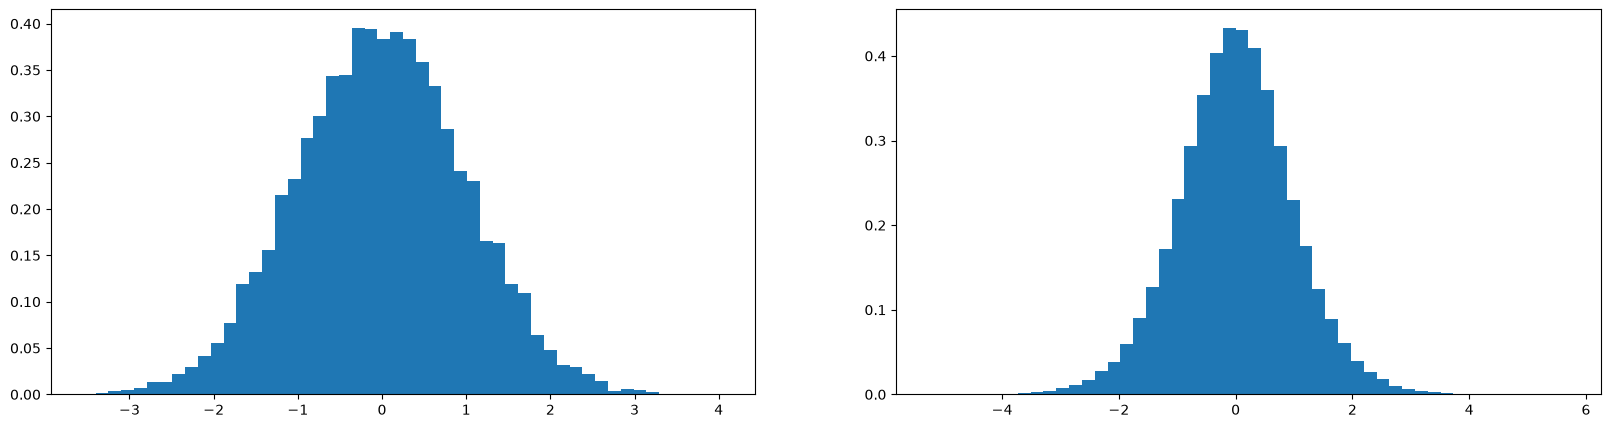

In [70]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w 
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density= True);

In [67]:
# same optimization as last time 
max_steps = 200000
batch_size = 32
lossi =[]

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,),generator = g)
    Xb, Yb = Xtr[ix],Ytr[ix] # batch X,Y

    #forward pass 
    emb = C[Xb] # embed the characters into the vectors
    embcat = emb.view(emb.shape[0],-1) #concatenate the vectors 
    hpreact = embcat @ W1 +b1 # hidden layer pre-activation 
    h = torch.tanh(hpreact) #hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Yb) #loss function

    # backward pass 
    for p in parameters:
        p.grad = None 
    loss.backward()

    #update 
    lr = 0.1 if i < 100000 else 0.01 #step learning rate decay
    for p in parameters:
        p.data += -lr *p.grad

    # track stats 
    if i % 10000 ==0: # print every once in a while 
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    lossi.append(loss.log10().item())
   

      0/ 200000:3.2347
  10000/ 200000:2.0295
  20000/ 200000:2.1641
  30000/ 200000:2.5580
  40000/ 200000:1.9543
  50000/ 200000:1.9926
  60000/ 200000:1.9887
  70000/ 200000:2.3205
  80000/ 200000:1.9438
  90000/ 200000:1.7627
 100000/ 200000:2.2678
 110000/ 200000:2.1151
 120000/ 200000:2.1513
 130000/ 200000:1.9865
 140000/ 200000:1.6409
 150000/ 200000:1.8682
 160000/ 200000:2.0819
 170000/ 200000:1.8036
 180000/ 200000:1.8079
 190000/ 200000:2.1939


In [50]:
h

tensor([[ 0.9730, -0.9816, -0.1626,  ..., -0.1901, -0.8978,  1.0000],
        [-0.9948, -0.2404,  0.9418,  ..., -0.9999,  0.9992,  1.0000],
        [ 0.9178, -0.7286,  0.9990,  ...,  0.1952, -0.9832,  1.0000],
        ...,
        [ 0.9282, -0.4961,  0.2488,  ...,  1.0000, -0.9998, -1.0000],
        [-0.9999, -0.9999, -0.9876,  ...,  0.9448, -1.0000, -0.9996],
        [-0.9954, -0.9980, -1.0000,  ...,  0.9990,  0.9620,  0.0504]],
       grad_fn=<TanhBackward0>)

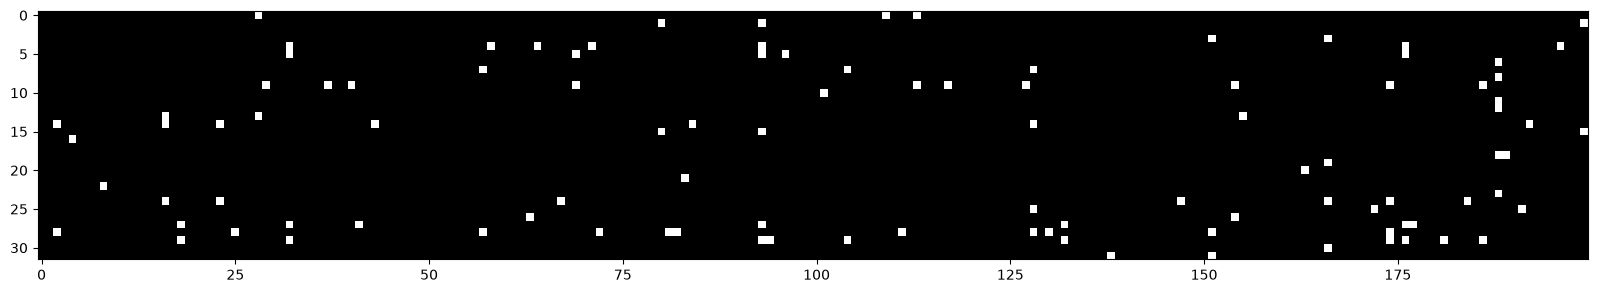

In [64]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation = 'nearest')

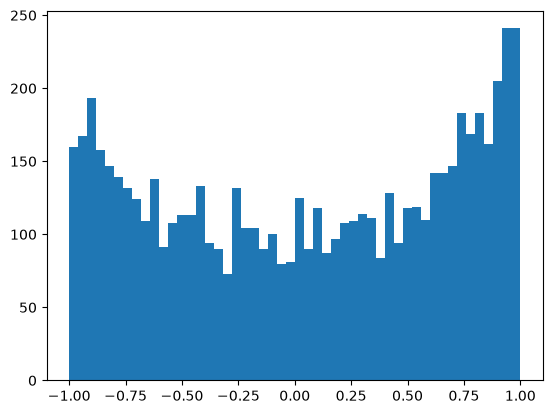

In [65]:
plt.hist(h.view(-1).tolist(), 50);

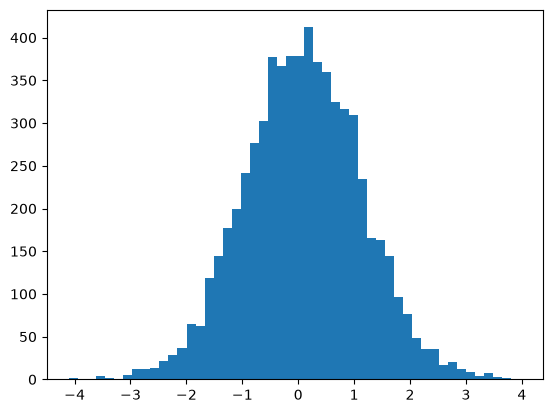

In [66]:
plt.hist(hpreact.view(-1).tolist(), 50);

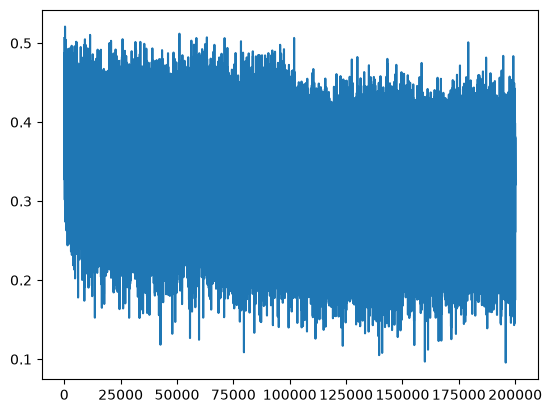

In [38]:
plt.plot(lossi)

In [68]:
@torch.no_grad() #this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        "train":(Xtr,Ytr),
        "val":(Xdev, Ydev),
        "test":(Xte, Yte),
    }[split]
    emb = C[x] #(N, block_size, n_embd)
    embcat = emb.view(emb.shape[0],-1) #concat into (N,block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) #(N, n_hidden)
    logits = h@ W2 +b2 #(N, vocab_size)
    loss = F.cross_entropy(logits,y)
    print(split, loss.item())

split_loss("train")
split_loss("val")


train 2.0339252948760986
val 2.108227014541626


In [16]:
# sample  from the model
g = torch.Generator().manual_seed(2147483647 +10)
for _ in range(20):
    out =[]
    context = [0] * block_size # initialize with all .....
    while True:
        # forward pass the neural net 
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1,-1) @ W1 + b1 )
        logits = h @ W2 +b2  
        probs = F.softmax(logits , dim=1)
        #sample from the distribution \
        ix = torch.multinomial(probs, num_samples=1, generator = g).item()
        # shift the context window and track the samples 
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special "." token , break 
        if ix == 0:
            break

    print("".join(itos[i] for i in out )) # decode and print the generated word 


carlah.
ambrilli.
kimri.
reh.
cassanden.
jazheen.
den.
art.
kaeli.
nellara.
chaiiv.
kaleigh.
ham.
jorn.
quint.
suline.
livani.
watelogdiaryni.
jacee.
durabee.
